<a href="https://colab.research.google.com/github/thuBv-123/Bai-tap-buoi-2/blob/main/Nhan%20dien%20khuon%20mat%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Nhận diện khuôn mặt

import numpy as np
import matplotlib.pyplot as plt
from keras.utils import load_img,img_to_array,to_categorical
from keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,BatchNormalization,Dropout
from keras.models import Sequential, load_model
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_dir='/content/drive/MyDrive/FACE_TRAIN'
val_dir='/content/drive/MyDrive/FACE_VAL'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest',
    brightness_range=[0.8,1.2],
)

val_datagen=ImageDataGenerator(rescale=1./255)

train_generator=train_datagen.flow_from_directory(
    train_dir,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical'
)
val_generator=val_datagen.flow_from_directory(
    val_dir,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical'
)


model=Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])


model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=100,
    validation_data=val_generator,
    validation_steps=len(val_generator)
)



Found 11 images belonging to 3 classes.
Found 3 images belonging to 3 classes.
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.2727 - loss: 1.1621 - val_accuracy: 0.6667 - val_loss: 1.1398
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3636 - loss: 1.1181 - val_accuracy: 0.3333 - val_loss: 1.1192
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.3636 - loss: 1.1324 - val_accuracy: 0.6667 - val_loss: 1.0838
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.4545 - loss: 1.0516 - val_accuracy: 0.3333 - val_loss: 1.0720
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.3636 - loss: 1.1252 - val_accuracy: 0.3333 - val_loss: 1.0510
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.3636 - loss: 1.0067 - val_accuracy: 0.3333 - val_loss: 1.0353
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.3636 - loss: 1.0301 - val_accuracy: 0.3333 - val_loss: 1.0229
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


Text(0.5, 1.0, 'Người này là:Taylor')

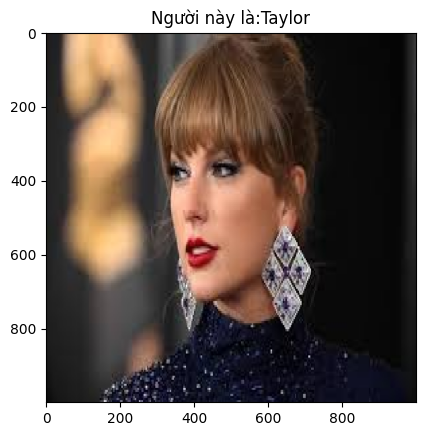

In [ ]:
img = load_img('/content/taylor.jpg', target_size=(1000, 1000))
plt.imshow(img)
img = img.resize((64, 64))
img_array = img_to_array(img) / 255.0
img_array = img_array.reshape(1, 64, 64, 3)
prediction = model.predict(img_array)
class_names = list(train_generator.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]
plt.title(f'Người này là:{predicted_class}')
